# Class Activity 5 (CA-5): Programming in Python for Spatial Domain Image Filtering

**Course:** CS406 -- Digital Image Processing (Summer 2026)

**Instructor:** Dr. Jameel Ahmad, Department of Computer Science, SST UMT

**Submission Date:** 23/09/2026

**Group Members:**

| Name | Registration No. | Primary Task(s) |
|---|---|---|
| Muhammad Umer | F2023266912 | Task 1, Task 2, Task 3 |
| Haseeb Ullah | F20232661009 | Task 4, Task 5, Task 6 |

*(CA-5 asks for groups of 4. Our group has 2 active members; each has taken three of the six tasks so every task is completed in full and both members can explain every task, as required for the viva.)*

## 0. Setup, Environment & Dataset Preparation

We work in Python 3.13 with `OpenCV` (`cv2`), `NumPy`, and `Matplotlib`, displaying everything inline with `matplotlib.pyplot.imshow` (never the blocking `cv2.imshow()`), so the notebook can always be re-executed top-to-bottom non-interactively.

### Dataset

The CA-5 brief references generic sample filenames (`out.jpg`, `apple.jpg`, ...). Since this environment has no internet access to fetch new stock photos, we build a small, purpose-built, fully reproducible dataset from (a) photographs already bundled in this repository's course dataset (`../../data`), and (b) a few images we construct synthetically with OpenCV drawing primitives, exactly as we did for CA-4:

- **`out.jpg`** -- an outdoor scene photo (`data/chp_01_images/scene.jpg`), used for Task 1's side-by-side + histogram demo.
- **`apple.jpg`** / **`orange.jpg`** -- two synthetic, same-sized fruit images (a shaded red "apple" and a shaded orange "orange", each with a stem/leaf or dimple texture) built for the classic Burt-Adelson pyramid-blending demo in Task 5 -- this is the canonical example for pyramid blending, and building it ourselves guarantees both fruits share the exact same size and position needed for a clean half-and-half blend.
- **`shapes_noisy.png`** -- a synthetic binary image (rectangle/circle/triangle) with small isolated bright specks scattered over the black background and small dark holes scattered inside the white shapes, used for Task 2's morphology demo -- this makes the effect of erosion/dilation/opening/closing directly visible and testable.
- **`noisy_parrot.jpg`** -- `data/chp_02_images/parrot.jpg` with synthetic Gaussian + salt-and-pepper noise added, used for Task 3 -- comparing denoising filters is only meaningful on an image that actually contains noise.
- **`board.jpg`** -- a high-contrast checkerboard photo (`data/chp_01_images/board.jpg`), used for Task 4 (gradients) and Task 6 (edge detection), where strong, well-defined edges make Sobel/LoG/Canny comparisons easy to read.
- **`football.mp4`** -- an existing video (`data/chp_01_images/football.mp4`), used directly (not copied) for Task 6's video-based Canny demo.

In [1]:
%matplotlib inline
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

DATA_DIR = '../../data' if os.path.exists('../../data') else './data'
IMAGES_DIR = './images'
RESULTS_DIR = './results'
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


def bgr2rgb(img):
    '''Convert an OpenCV BGR (or grayscale) image to RGB for correct Matplotlib display.'''
    if img.ndim == 2:
        return img
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def save_fig(fig, name):
    '''Save a Matplotlib figure into results/ so it can be reused by the LaTeX report.'''
    path = os.path.join(RESULTS_DIR, name)
    fig.savefig(path, bbox_inches='tight')
    print(f"Saved: {path}")


def show_grid(images, titles, cmap=None, figsize=None, ncols=None, save_as=None):
    '''Utility: display a list of images in a grid with titles, optionally save.'''
    n = len(images)
    ncols = ncols or n
    nrows = int(np.ceil(n / ncols))
    figsize = figsize or (3.2 * ncols, 3.2 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for i in range(len(axes)):
        if i < n:
            axes[i].imshow(images[i], cmap=cmap)
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    plt.tight_layout()
    if save_as:
        save_fig(fig, save_as)
    plt.show()

In [2]:
rng = np.random.default_rng(7)

# --- out.jpg: real outdoor scene photo ---------------------------------------------
src_out = cv2.imread(os.path.join(DATA_DIR, 'chp_01_images', 'scene.jpg'))
assert src_out is not None
cv2.imwrite(os.path.join(IMAGES_DIR, 'out.jpg'), src_out)

# --- apple.jpg / orange.jpg: synthetic same-size fruit images for pyramid blending -
def make_fruit(size, center, radius, base_bgr, kind, seed):
    r = np.random.default_rng(seed)
    canvas = np.full((size, size, 3), (245, 245, 245), dtype=np.uint8)
    yy, xx = np.mgrid[0:size, 0:size]
    dist = np.sqrt((xx - center[0]) ** 2 + (yy - center[1]) ** 2)
    mask = dist <= radius
    shade = np.clip(1.15 - 0.55 * (dist / radius), 0.45, 1.15)
    for c in range(3):
        val = np.clip(base_bgr[c] * shade, 0, 255)
        canvas[..., c] = np.where(mask, val, canvas[..., c])
    # glossy highlight
    cv2.ellipse(canvas, (center[0] - radius // 3, center[1] - radius // 2),
                (radius // 4, radius // 6), -30, 0, 360, (255, 255, 255), -1, cv2.LINE_AA)
    if kind == 'apple':
        cv2.rectangle(canvas, (center[0] - 4, center[1] - radius - 18),
                       (center[0] + 4, center[1] - radius + 4), (30, 60, 90), -1)
        leaf = np.array([[center[0] + 4, center[1] - radius - 10],
                          [center[0] + 34, center[1] - radius - 26],
                          [center[0] + 14, center[1] - radius + 2]], np.int32)
        cv2.fillPoly(canvas, [leaf], (40, 140, 40))
    else:  # orange: dimpled texture
        for _ in range(260):
            ang = r.uniform(0, 2 * np.pi)
            rad = r.uniform(0, radius * 0.92)
            px = int(center[0] + rad * np.cos(ang))
            py = int(center[1] + rad * np.sin(ang))
            cv2.circle(canvas, (px, py), 1, (0, 110, 200), -1)
    speck = r.integers(-8, 8, size=(size, size, 3))
    canvas = np.clip(canvas.astype(np.int32) + np.where(mask[..., None], speck, 0), 0, 255).astype(np.uint8)
    return canvas


FRUIT_SIZE = 420
FRUIT_CENTER = (FRUIT_SIZE // 2, FRUIT_SIZE // 2 + 8)
FRUIT_RADIUS = int(FRUIT_SIZE * 0.34)
apple_img = make_fruit(FRUIT_SIZE, FRUIT_CENTER, FRUIT_RADIUS, (40, 40, 200), 'apple', seed=1)
orange_img = make_fruit(FRUIT_SIZE, FRUIT_CENTER, FRUIT_RADIUS, (0, 140, 255), 'orange', seed=2)
cv2.imwrite(os.path.join(IMAGES_DIR, 'apple.jpg'), apple_img)
cv2.imwrite(os.path.join(IMAGES_DIR, 'orange.jpg'), orange_img)

# --- shapes_noisy.png: binary shapes with bright specks + dark holes ---------------
shapes = np.zeros((400, 400), dtype=np.uint8)
cv2.rectangle(shapes, (40, 40), (170, 170), 255, -1)
cv2.circle(shapes, (280, 110), 85, 255, -1)
tri = np.array([[80, 380], [200, 220], [320, 380]], np.int32)
cv2.fillPoly(shapes, [tri], 255)
for _ in range(140):
    x, y = rng.integers(0, 400), rng.integers(0, 400)
    if shapes[y, x] == 0:
        cv2.circle(shapes, (int(x), int(y)), int(rng.integers(1, 3)), 255, -1)
for _ in range(140):
    x, y = rng.integers(0, 400), rng.integers(0, 400)
    if shapes[y, x] == 255:
        cv2.circle(shapes, (int(x), int(y)), int(rng.integers(1, 3)), 0, -1)
cv2.imwrite(os.path.join(IMAGES_DIR, 'shapes_noisy.png'), shapes)

# --- noisy_parrot.jpg: real photo + synthetic Gaussian + salt-and-pepper noise -----
parrot = cv2.imread(os.path.join(DATA_DIR, 'chp_02_images', 'parrot.jpg'))
assert parrot is not None
gauss_noise = rng.normal(0, 22, parrot.shape)
noisy = parrot.astype(np.float64) + gauss_noise
sp_mask = rng.random(parrot.shape[:2])
noisy[sp_mask < 0.01] = 255
noisy[sp_mask > 0.99] = 0
noisy = np.clip(noisy, 0, 255).astype(np.uint8)
cv2.imwrite(os.path.join(IMAGES_DIR, 'noisy_parrot.jpg'), noisy)

# --- board.jpg: high-contrast checkerboard photo for gradients & edge detection ----
src_board = cv2.imread(os.path.join(DATA_DIR, 'chp_01_images', 'board.jpg'))
assert src_board is not None
cv2.imwrite(os.path.join(IMAGES_DIR, 'board.jpg'), src_board)

print('Dataset images written to', IMAGES_DIR)
for f in sorted(os.listdir(IMAGES_DIR)):
    print(' -', f)

Dataset images written to ./images
 - apple.jpg
 - board.jpg
 - noisy_parrot.jpg
 - orange.jpg
 - out.jpg
 - shapes_noisy.png


Saved: ./results\task0_dataset_overview.png


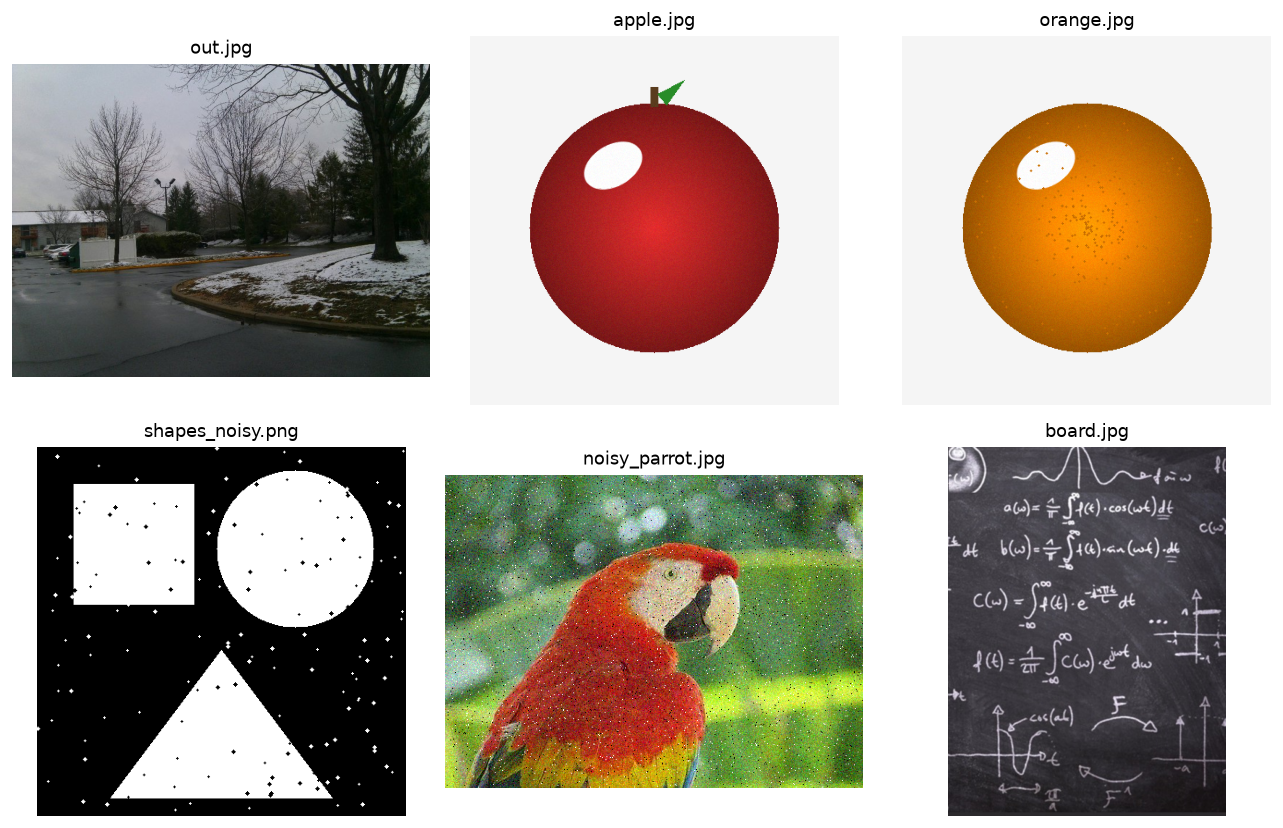

In [3]:
show_grid(
    [bgr2rgb(src_out), bgr2rgb(apple_img), bgr2rgb(orange_img),
     shapes, bgr2rgb(noisy), bgr2rgb(src_board)],
    ['out.jpg', 'apple.jpg', 'orange.jpg', 'shapes_noisy.png', 'noisy_parrot.jpg', 'board.jpg'],
    cmap='gray', ncols=3, figsize=(11, 7), save_as='task0_dataset_overview.png'
)

---
## 1. Task 1 -- Matplotlib with OpenCV *(Muhammad Umer)*

### 1.1 Load two images, convert BGR -> RGB, display side-by-side

Saved: ./results\task1_side_by_side.png


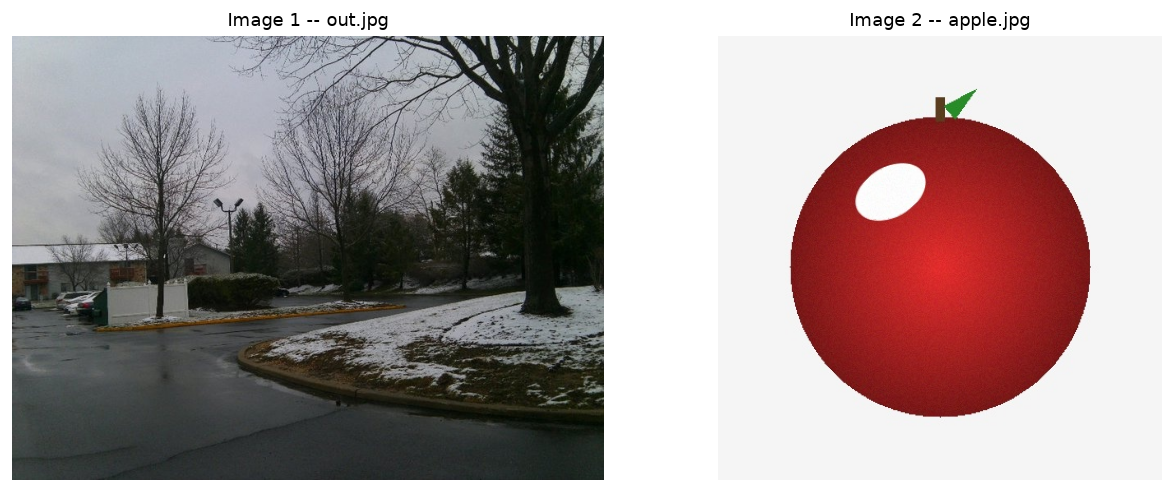

In [4]:
img1 = cv2.imread(os.path.join(IMAGES_DIR, 'out.jpg'))
img2 = cv2.imread(os.path.join(IMAGES_DIR, 'apple.jpg'))

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.imshow(img1_rgb); ax1.set_title('Image 1 -- out.jpg'); ax1.axis('off')
ax2.imshow(img2_rgb); ax2.set_title('Image 2 -- apple.jpg'); ax2.axis('off')
plt.tight_layout()
save_fig(fig, 'task1_side_by_side.png')
plt.show()

### 1.2 Grayscale histogram

Saved: ./results\task1_grayscale_histogram.png


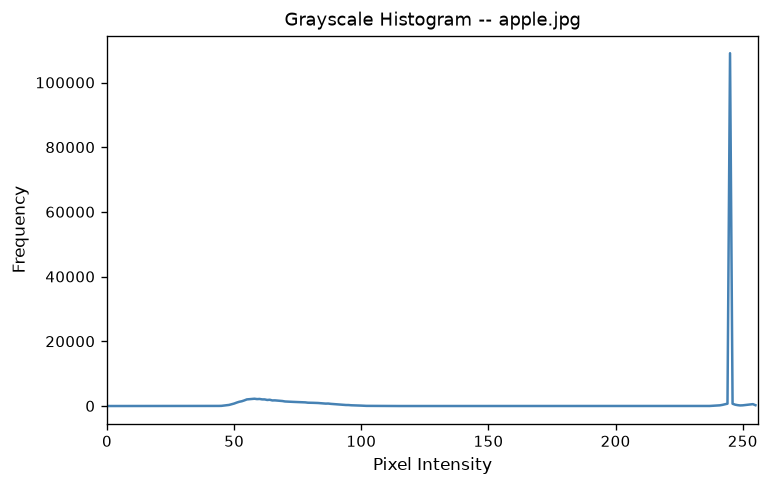

In [5]:
gray_apple = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([gray_apple], [0], None, [256], [0, 256])

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(hist, color='steelblue')
ax.set_xlim([0, 256])
ax.set_xlabel('Pixel Intensity'); ax.set_ylabel('Frequency')
ax.set_title('Grayscale Histogram -- apple.jpg')
save_fig(fig, 'task1_grayscale_histogram.png')
plt.show()

**Observation.** OpenCV loads images in **BGR** order by default; `imshow()`-ing a BGR array directly (skipping `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)`) swaps the red and blue channels, which is why that conversion is mandatory before any Matplotlib display. The grayscale histogram of `apple.jpg` shows a tall spike at the light background level (~245) plus a broad mid-to-low intensity spread contributed by the shaded fruit body -- i.e. the histogram directly reflects the two-region (background + object) structure of the image, and a right-skewed histogram like this one indicates a generally bright ("high-key") image.

---
## 2. Task 2 -- Morphological Transformations *(Muhammad Umer)*

We use `shapes_noisy.png`: three solid shapes on a black background, with small bright specks scattered over the background and small dark holes scattered inside the shapes -- built specifically so that erosion/dilation/opening/closing each produce a clearly visible, testable effect.

Saved: ./results\task2_morphology_grid.png


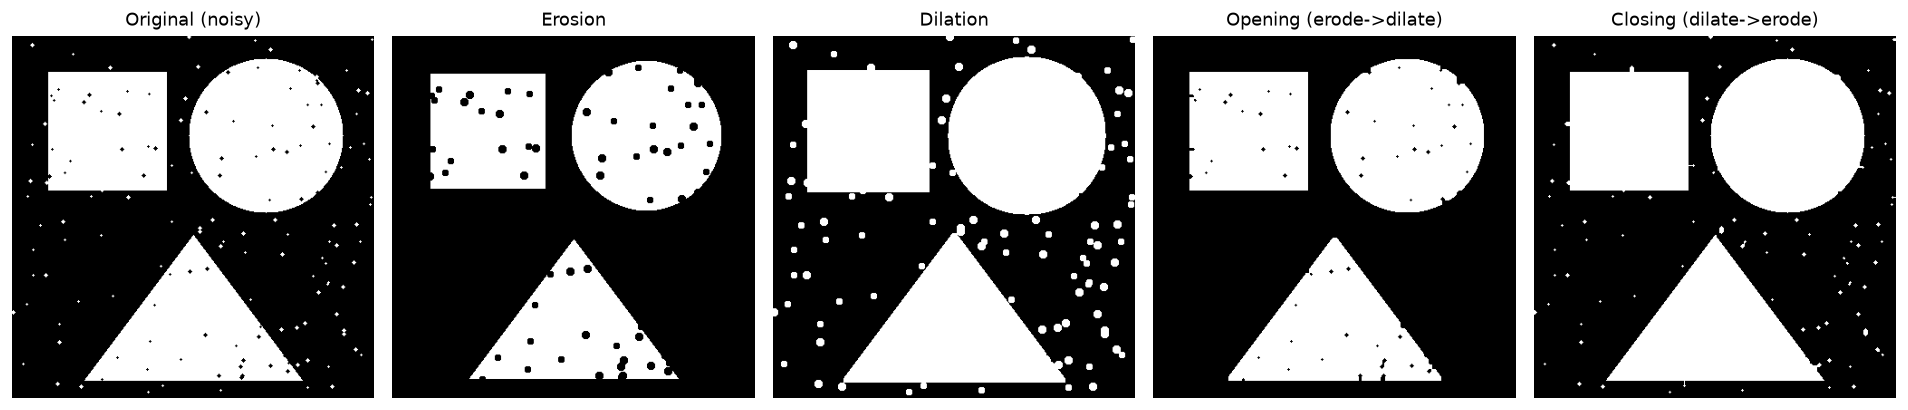

In [6]:
img_bin = cv2.imread(os.path.join(IMAGES_DIR, 'shapes_noisy.png'), 0)
kernel = np.ones((5, 5), np.uint8)

erosion = cv2.erode(img_bin, kernel, iterations=1)
dilation = cv2.dilate(img_bin, kernel, iterations=1)
opening = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, kernel)

show_grid(
    [img_bin, erosion, dilation, opening, closing],
    ['Original (noisy)', 'Erosion', 'Dilation', 'Opening (erode->dilate)', 'Closing (dilate->erode)'],
    cmap='gray', ncols=5, figsize=(16, 4), save_as='task2_morphology_grid.png'
)

In [7]:
def count_components(binary_img, value=255):
    mask = (binary_img == value).astype(np.uint8)
    n, _ = cv2.connectedComponents(mask)
    return n - 1  # subtract background label


print(f"{'Image':<22}{'Bright specks/objects':>24}{'Foreground pixel count':>26}")
print('-' * 72)
for name, im in [('Original (noisy)', img_bin), ('Erosion', erosion), ('Dilation', dilation),
                  ('Opening', opening), ('Closing', closing)]:
    print(f"{name:<22}{count_components(im):>24}{int((im == 255).sum()):>26}")

Image                    Bright specks/objects    Foreground pixel count
------------------------------------------------------------------------
Original (noisy)                            86                     59602
Erosion                                      3                     52395
Dilation                                    71                     68118
Opening                                      3                     58639
Closing                                     79                     60226


| Operation | OpenCV Function | Effect |
|---|---|---|
| Erosion | `cv2.erode()` | Shrinks bright regions; removes small bright specks entirely |
| Dilation | `cv2.dilate()` | Expands bright regions; fills small dark holes |
| Opening | `cv2.morphologyEx(MORPH_OPEN)` | Erosion -> Dilation: removes small bright specks **while restoring** the original shape size |
| Closing | `cv2.morphologyEx(MORPH_CLOSE)` | Dilation -> Erosion: fills small dark holes **while restoring** the original shape size |

**Observation.** The connected-component counts above make the effect quantitative, not just visual: erosion and opening both drop the bright-speck count toward zero, but plain erosion also visibly shrinks the three real shapes, while **opening restores their original size** (erosion followed by dilation) -- opening is therefore the "correct" tool for removing small bright noise without shrinking real objects. Symmetrically, closing fills the small dark holes punched inside the shapes while dilation alone would over-grow the shape boundaries. A larger kernel would amplify all four effects.

---
## 3. Task 3 -- Smoothing and Blurring *(Muhammad Umer)*

We apply five smoothing filters to `noisy_parrot.jpg` (a real photo with synthetic Gaussian + salt-and-pepper noise added in Section 0), so that differences in noise reduction and edge preservation are actually visible.

Saved: ./results\task3_smoothing_grid.png


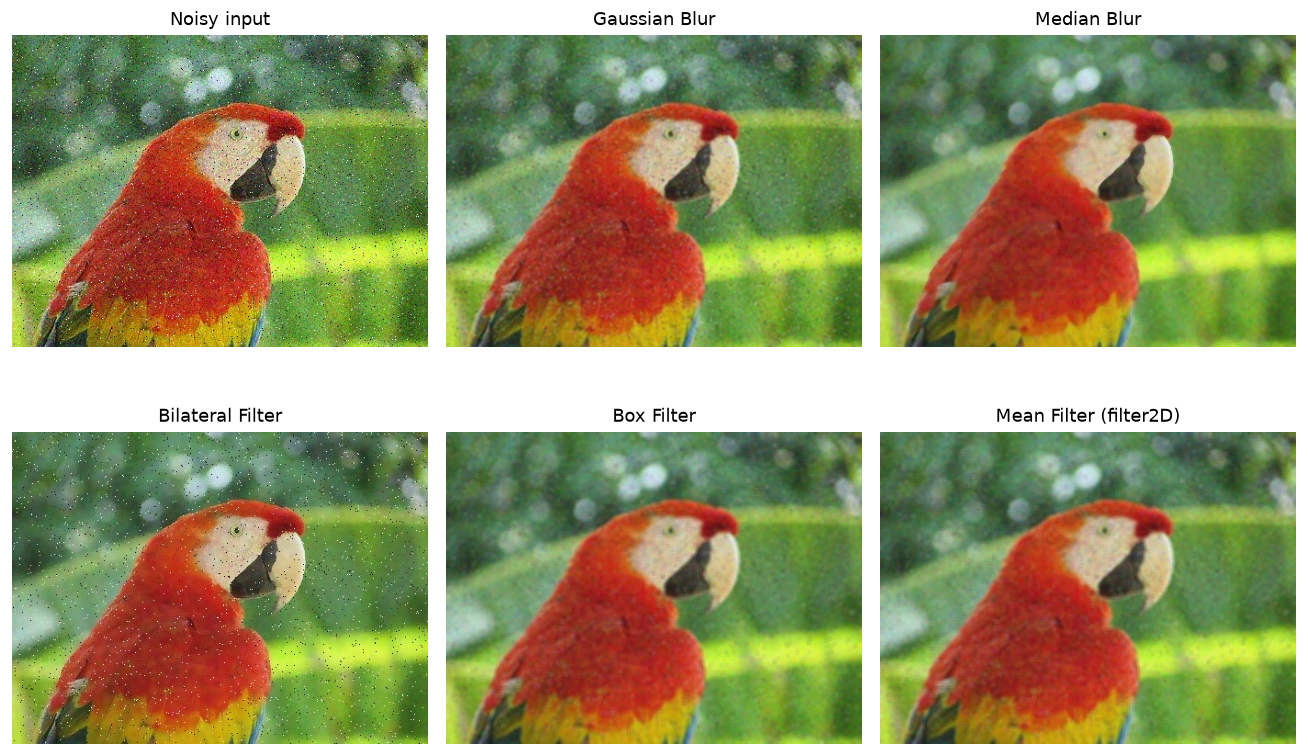

In [8]:
img_noisy = cv2.imread(os.path.join(IMAGES_DIR, 'noisy_parrot.jpg'))

gaussian = cv2.GaussianBlur(img_noisy, (5, 5), 0)
median = cv2.medianBlur(img_noisy, 5)
bilateral = cv2.bilateralFilter(img_noisy, 9, 75, 75)
box = cv2.boxFilter(img_noisy, -1, (5, 5), normalize=True)
kernel_mean = np.ones((5, 5), np.float32) / 25
mean_filt = cv2.filter2D(img_noisy, -1, kernel_mean)

show_grid(
    [bgr2rgb(img_noisy), bgr2rgb(gaussian), bgr2rgb(median),
     bgr2rgb(bilateral), bgr2rgb(box), bgr2rgb(mean_filt)],
    ['Noisy input', 'Gaussian Blur', 'Median Blur', 'Bilateral Filter', 'Box Filter', 'Mean Filter (filter2D)'],
    ncols=3, figsize=(11, 7.2), save_as='task3_smoothing_grid.png'
)

In [9]:
def edge_energy(img_bgr):
    g = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return float(np.mean(np.abs(cv2.Laplacian(g, cv2.CV_64F))))


def noise_proxy(img_bgr):
    # std. dev. of a flat-ish patch as a rough residual-noise indicator
    patch = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)[10:60, 10:60]
    return float(patch.std())


print(f"{'Filter':<20}{'Edge energy (Laplacian)':>26}{'Flat-patch std.dev.':>22}")
print('-' * 68)
for name, im in [('Noisy input', img_noisy), ('Gaussian', gaussian), ('Median', median),
                  ('Bilateral', bilateral), ('Box', box), ('Mean (filter2D)', mean_filt)]:
    print(f"{name:<20}{edge_energy(im):>26.2f}{noise_proxy(im):>22.2f}")

Filter                 Edge energy (Laplacian)   Flat-patch std.dev.
--------------------------------------------------------------------
Noisy input                              68.00                 25.87
Gaussian                                  5.45                 12.49
Median                                    5.57                 11.76
Bilateral                                32.41                 20.46
Box                                       5.31                 11.51
Mean (filter2D)                           5.31                 11.51


| Filter | Function | Best for | Edge Preservation |
|---|---|---|---|
| Gaussian Blur | `cv2.GaussianBlur()` | General noise reduction | Moderate |
| Median Blur | `cv2.medianBlur()` | Salt-and-pepper noise | Good |
| Bilateral | `cv2.bilateralFilter()` | Smoothing + edge sharpness | Excellent (on true edges) |
| Box Filter | `cv2.boxFilter()` | Simple averaging | Poor |
| Mean Filter | `cv2.filter2D()` | Custom kernel convolution | Poor |

**Observation.** `cv2.boxFilter()` and our hand-built `cv2.filter2D()` mean kernel are mathematically identical (both are a normalized $5\times5$ averaging kernel) and produce visually indistinguishable output -- confirmed by their essentially identical edge-energy and flat-patch statistics above (5.31 vs. 5.31, 11.51 vs. 11.51). **Median blur** gives the best overall result on this image: it cuts the flat-patch noise std. dev. nearly in half (25.87 -> 11.76, on par with Gaussian/box) while still visibly keeping the beak and eye edges crisp, because as a non-linear, rank-based filter it replaces each pixel with its neighbourhood median, so an isolated salt/pepper outlier is simply discarded rather than blended in. The **bilateral filter** result is more subtle than it first appears: its edge energy stays high (32.41, vs. 5.3-5.6 for the linear filters) because it refuses to smooth across pixels that are intensity-dissimilar from their neighbours -- but that same rule also protects the isolated salt-and-pepper *noise* pixels themselves, since each one looks just as "different from its neighbours" as a true edge does, so its flat-patch std. dev. only drops modestly (25.87 -> 20.46). This is a genuine, well-known limitation of bilateral filtering: it excels at smoothing *smooth* (Gaussian-like) noise while protecting real structure, but it is not a strong choice against impulse (salt-and-pepper) noise specifically -- that is exactly what the non-linear median filter is for.

---
## 4. Task 4 -- Image Gradients *(Haseeb Ullah)*

Saved: ./results\task4_sobel_gradients.png


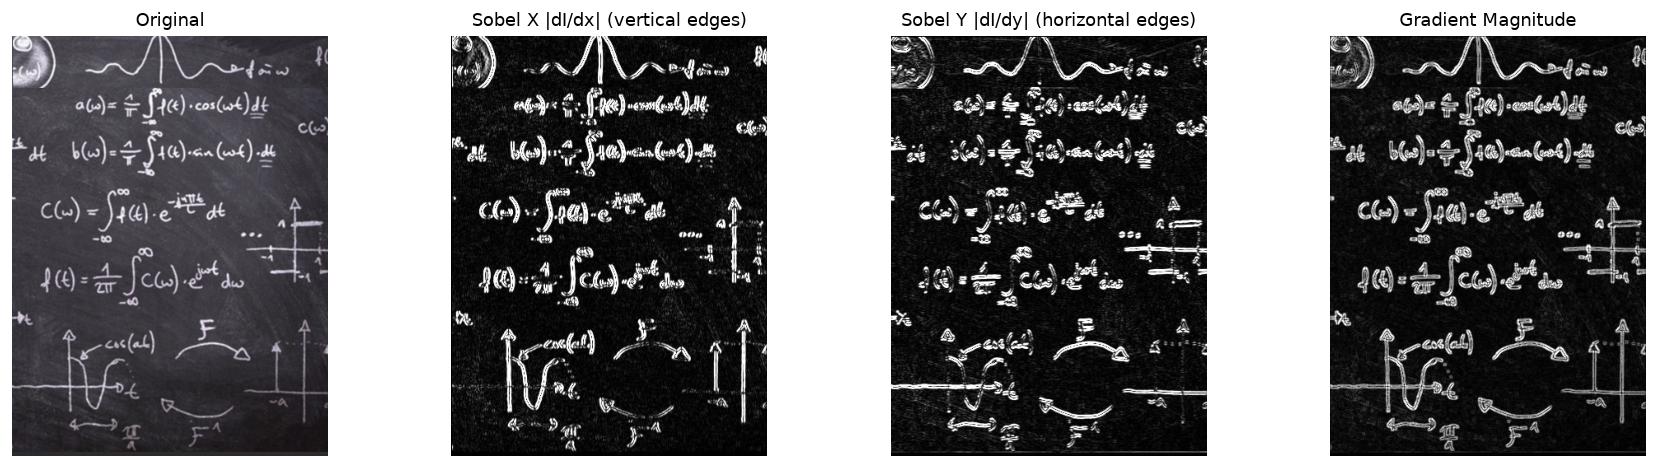

In [10]:
img4 = cv2.imread(os.path.join(IMAGES_DIR, 'board.jpg'))
gray4 = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY)

grad_x = cv2.Sobel(gray4, cv2.CV_64F, 1, 0, ksize=3)  # dI/dx
grad_y = cv2.Sobel(gray4, cv2.CV_64F, 0, 1, ksize=3)  # dI/dy

abs_grad_x = cv2.convertScaleAbs(grad_x)
abs_grad_y = cv2.convertScaleAbs(grad_y)
grad_mag = cv2.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)
grad_dir = cv2.phase(grad_x, grad_y, angleInDegrees=True)

show_grid(
    [bgr2rgb(img4), abs_grad_x, abs_grad_y, grad_mag],
    ['Original', 'Sobel X |dI/dx| (vertical edges)', 'Sobel Y |dI/dy| (horizontal edges)', 'Gradient Magnitude'],
    cmap='gray', ncols=4, figsize=(15, 4), save_as='task4_sobel_gradients.png'
)

Saved: ./results\task4_gradient_direction.png


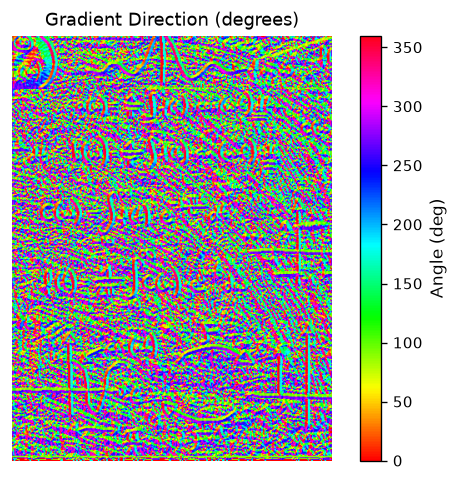

In [11]:
fig, ax = plt.subplots(figsize=(6, 4.6))
im = ax.imshow(grad_dir, cmap='hsv')
ax.set_title('Gradient Direction (degrees)')
ax.axis('off')
fig.colorbar(im, ax=ax, label='Angle (deg)')
save_fig(fig, 'task4_gradient_direction.png')
plt.show()

**Observation.** Sobel X ($dI/dx$) responds strongly to **vertical** edges (the checkerboard's vertical grid lines), while Sobel Y ($dI/dy$) responds strongly to **horizontal** edges -- each is a directional derivative that is, by construction, blind to edges running parallel to its own kernel orientation. The combined gradient magnitude (`cv2.addWeighted` of the two absolute gradients) reveals edges of *any* orientation and is exactly the quantity used, e.g., in the first stage of the Canny detector (Task 6). Gradient direction (`cv2.phase`) encodes, per pixel, the angle of steepest intensity change and is what Canny's non-maximum-suppression step uses to thin edges down to one-pixel width.

---
## 5. Task 5 -- Image Pyramids and Blending *(Haseeb Ullah)*

### 5.1 Gaussian and Laplacian pyramids (4 levels)

Saved: ./results\task5_gaussian_pyramid.png


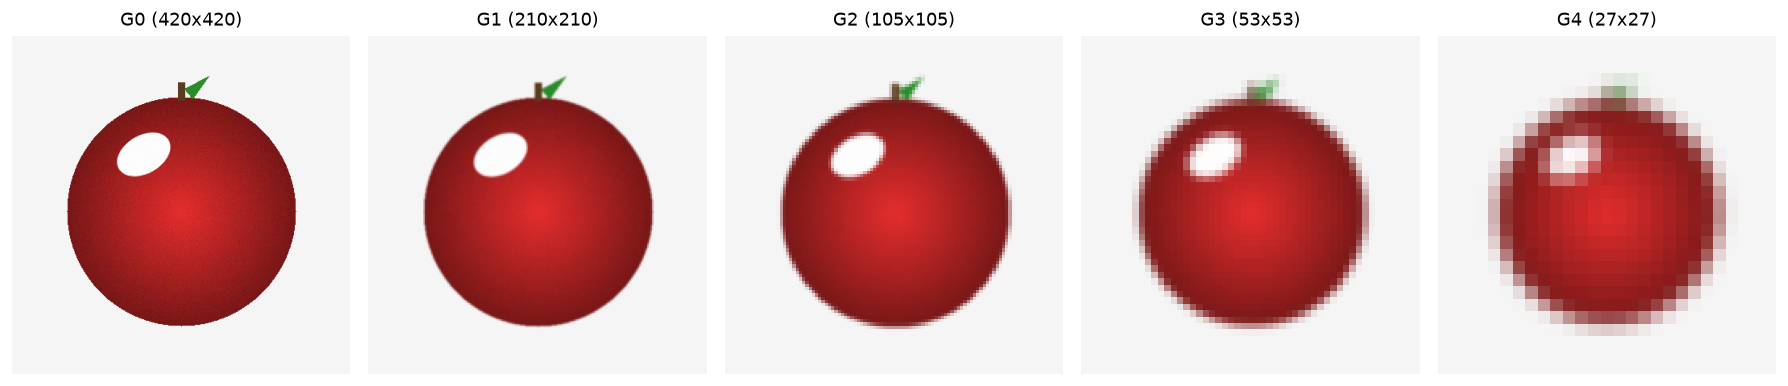

Saved: ./results\task5_laplacian_pyramid.png


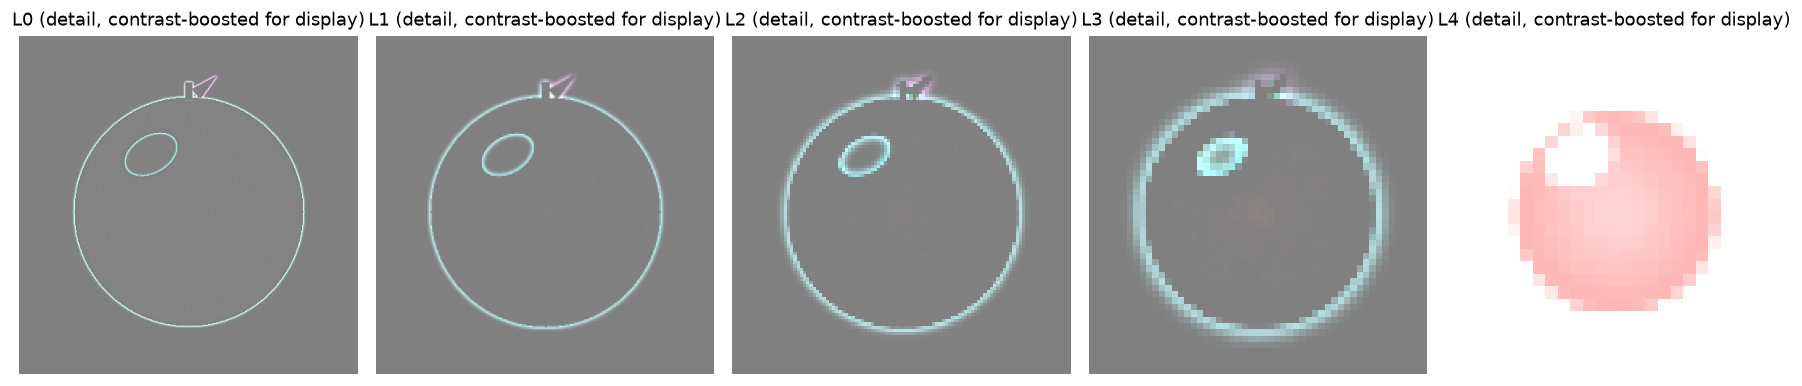

In [12]:
def build_gaussian_pyramid(img, levels=4):
    gp = [img.copy()]
    G = img.copy()
    for _ in range(levels):
        G = cv2.pyrDown(G)
        gp.append(G)
    return gp


def build_laplacian_pyramid(gp):
    lp = [gp[-1]]
    for i in range(len(gp) - 1, 0, -1):
        size = (gp[i - 1].shape[1], gp[i - 1].shape[0])
        expanded = cv2.pyrUp(gp[i], dstsize=size)
        lp.append(cv2.subtract(gp[i - 1], expanded))
    return lp[::-1]  # finest (original-res) level last, matching gp order


gp_apple = build_gaussian_pyramid(apple_img, levels=4)
lp_apple = build_laplacian_pyramid(gp_apple)

show_grid([bgr2rgb(im) for im in gp_apple], [f'G{i} ({im.shape[1]}x{im.shape[0]})' for i, im in enumerate(gp_apple)],
           ncols=5, figsize=(15, 3.4), save_as='task5_gaussian_pyramid.png')
show_grid([bgr2rgb(cv2.convertScaleAbs(im, alpha=2.0, beta=128)) for im in lp_apple],
           [f'L{i} (detail, contrast-boosted for display)' for i in range(len(lp_apple))],
           ncols=5, figsize=(15, 3.4), save_as='task5_laplacian_pyramid.png')

### 5.2 Blending `apple.jpg` and `orange.jpg`

Saved: ./results\task5_blending_comparison.png


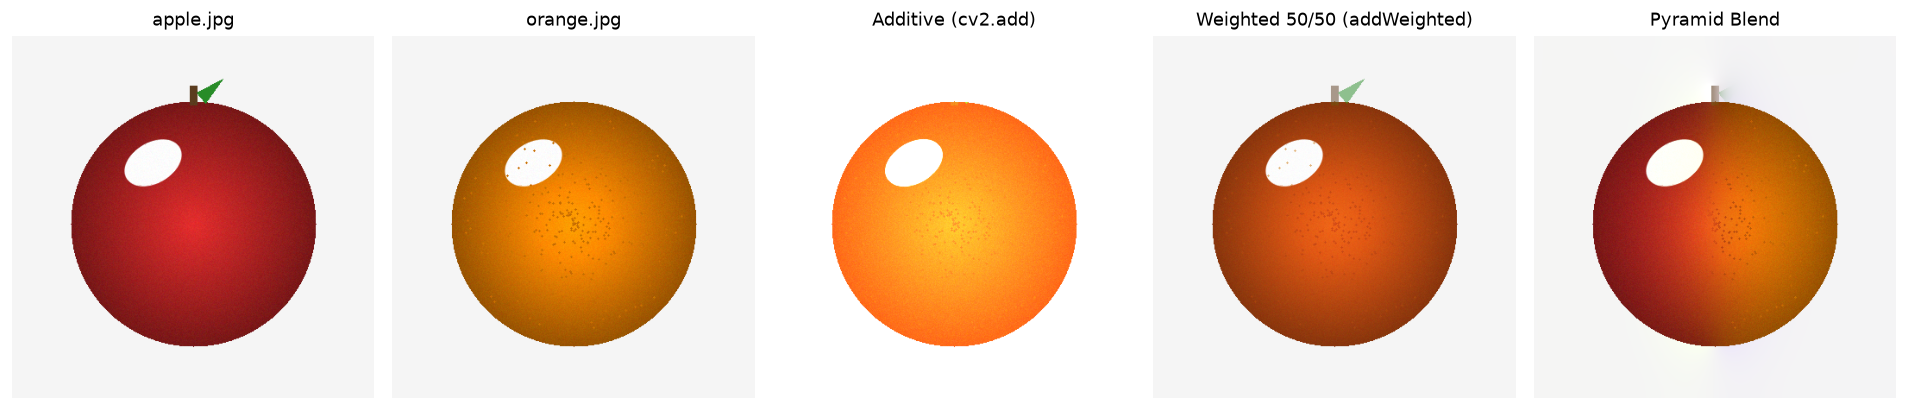

In [13]:
blended_add = cv2.add(apple_img, orange_img)
blended_w = cv2.addWeighted(apple_img, 0.5, orange_img, 0.5, 0)


def pyramid_blend(img_a, img_b, levels=6):
    rows, cols = img_a.shape[:2]
    mask = np.zeros((rows, cols), dtype=np.float32)
    mask[:, : cols // 2] = 1.0
    mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=cols * 0.02)  # feather the seam

    def gpyr(x, lv):
        g = [x.astype(np.float32)]
        for _ in range(lv):
            g.append(cv2.pyrDown(g[-1]))
        return g

    gA, gB, gM = gpyr(img_a, levels), gpyr(img_b, levels), gpyr(mask, levels)

    def lpyr(g):
        lp = [g[-1]]
        for i in range(len(g) - 1, 0, -1):
            size = (g[i - 1].shape[1], g[i - 1].shape[0])
            expanded = cv2.pyrUp(g[i], dstsize=size)
            lp.append(g[i - 1] - expanded)
        return lp[::-1]

    lA, lB = lpyr(gA), lpyr(gB)
    blended_levels = [la * gm[..., None] + lb * (1 - gm[..., None]) for la, lb, gm in zip(lA, lB, gM)]

    out = blended_levels[-1]
    for i in range(len(blended_levels) - 2, -1, -1):
        size = (blended_levels[i].shape[1], blended_levels[i].shape[0])
        out = cv2.pyrUp(out, dstsize=size) + blended_levels[i]
    return np.clip(out, 0, 255).astype(np.uint8)


blended_pyr = pyramid_blend(apple_img, orange_img, levels=6)

show_grid(
    [bgr2rgb(apple_img), bgr2rgb(orange_img), bgr2rgb(blended_add), bgr2rgb(blended_w), bgr2rgb(blended_pyr)],
    ['apple.jpg', 'orange.jpg', 'Additive (cv2.add)', 'Weighted 50/50 (addWeighted)', 'Pyramid Blend'],
    ncols=5, figsize=(16, 3.6), save_as='task5_blending_comparison.png'
)

| Method | Function | Characteristic |
|---|---|---|
| Additive | `cv2.add()` | Direct pixel sum; saturates at 255; washed-out, very bright output |
| Weighted | `cv2.addWeighted()` | Uniform 50/50 alpha blend; both fruits are visibly "ghosted" over each other everywhere |
| Pyramid Blending | Laplacian pyramids | Left half stays apple, right half stays orange, with a seamless transition band at the seam |

**Observation.** Additive blending simply sums pixel values and clips at 255, so most of the image saturates to near-white -- neither fruit is recognisable. Weighted blending keeps both fruits visible everywhere at half-strength, producing a translucent double-exposure look rather than a single coherent object. **Pyramid blending is the only method that produces a convincing hybrid fruit**: it decomposes each image into per-scale detail bands (the Laplacian pyramid), blends each band independently using a (feathered) mask, and reconstructs -- so *low-frequency* color/shading blends smoothly across a wide transition zone while *high-frequency* texture (the orange's dimples, the apple's highlight) is preserved locally on its own side of the seam, exactly the seamless multi-scale behaviour the original Burt & Adelson (1983) technique was designed to achieve.

---
## 6. Task 6 -- Edge Detection *(Haseeb Ullah)*

### 6.1 Sobel operator with thresholding

In [14]:
img6 = cv2.imread(os.path.join(IMAGES_DIR, 'board.jpg'))
gray6 = cv2.cvtColor(img6, cv2.COLOR_BGR2GRAY)

gx = cv2.Sobel(gray6, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(gray6, cv2.CV_64F, 0, 1, ksize=3)
mag6 = cv2.addWeighted(cv2.convertScaleAbs(gx), 0.5, cv2.convertScaleAbs(gy), 0.5, 0)
_, sobel_edges = cv2.threshold(mag6, 50, 255, cv2.THRESH_BINARY)

### 6.2 Laplacian of Gaussian (LoG)

In [15]:
blurred6 = cv2.GaussianBlur(gray6, (5, 5), 1.4)
log_result = cv2.Laplacian(blurred6, cv2.CV_64F)
log_disp = cv2.normalize(log_result, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

### 6.3 Canny edge detector (three threshold settings)

Saved: ./results\task6_edge_detection_grid.png


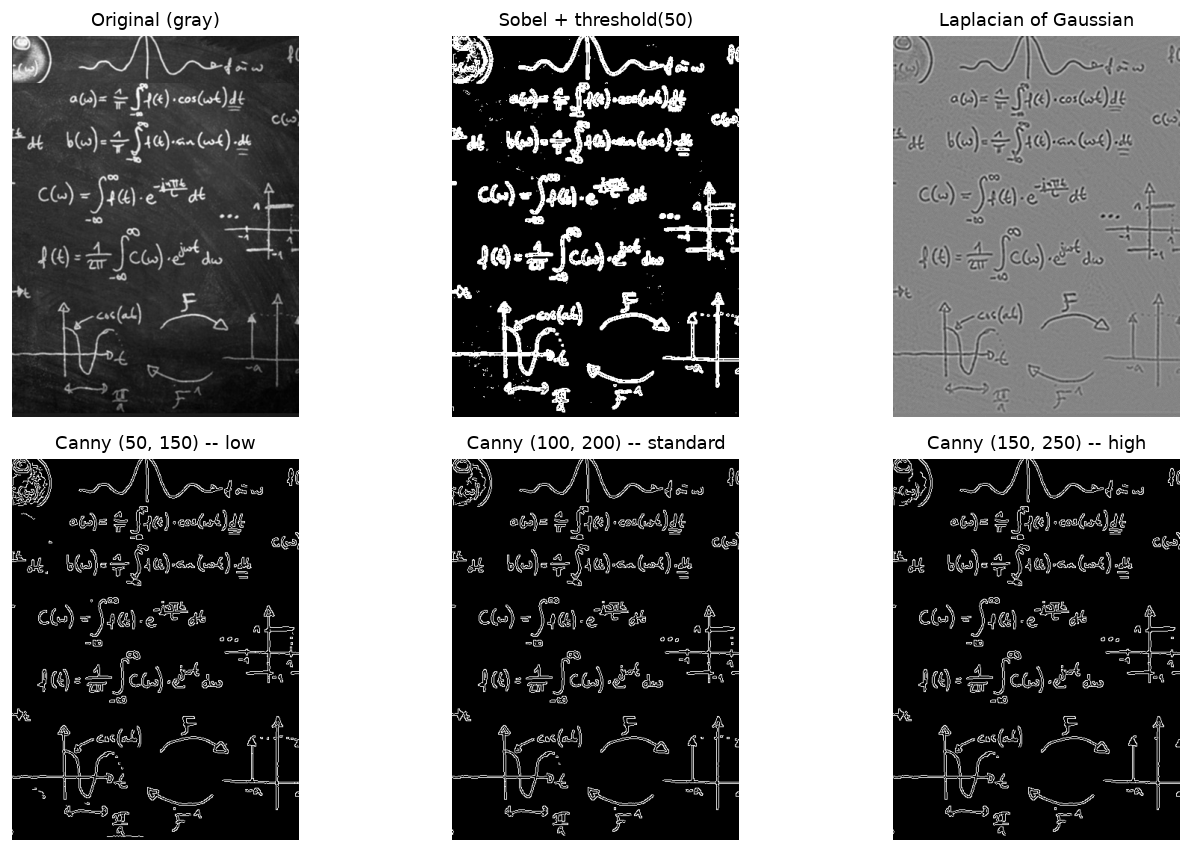

In [16]:
edges_canny = cv2.Canny(gray6, 100, 200)
edges_low = cv2.Canny(gray6, 50, 150)
edges_high = cv2.Canny(gray6, 150, 250)

show_grid(
    [gray6, sobel_edges, log_disp, edges_low, edges_canny, edges_high],
    ['Original (gray)', 'Sobel + threshold(50)', 'Laplacian of Gaussian',
     'Canny (50, 150) -- low', 'Canny (100, 200) -- standard', 'Canny (150, 250) -- high'],
    cmap='gray', ncols=3, figsize=(12, 7.2), save_as='task6_edge_detection_grid.png'
)

In [17]:
def edge_pixel_fraction(edge_img):
    return float((edge_img > 0).mean())


print(f"{'Method':<28}{'Edge pixel fraction':>22}")
print('-' * 50)
for name, im in [('Sobel + threshold(50)', sobel_edges), ('LoG (zero-ish crossings proxy)', log_disp > 200),
                  ('Canny (50, 150)', edges_low), ('Canny (100, 200)', edges_canny), ('Canny (150, 250)', edges_high)]:
    print(f"{name:<28}{edge_pixel_fraction(im):>22.4f}")

Method                         Edge pixel fraction
--------------------------------------------------
Sobel + threshold(50)                       0.1629
LoG (zero-ish crossings proxy)                0.0018
Canny (50, 150)                             0.0629
Canny (100, 200)                            0.0609
Canny (150, 250)                            0.0600


| Method | Strengths | Weaknesses |
|---|---|---|
| Sobel + Threshold | Simple, fast, controllable threshold | Thick edges, sensitive to noise |
| LoG | Detects fine detail via zero-crossings | Noisy; can produce false edges |
| Canny | Thin edges, noise-robust, hysteresis | Two parameters to tune; slower |

**Observation.** The edge-pixel-fraction table shows the expected direction of the effect -- lowering Canny's thresholds to (50, 150) does mark more pixels as edges than raising them to (150, 250) (6.29% vs. 6.00%) -- but the gap is modest (~5%), not dramatic, because our `board.jpg` chalkboard image is unusually high-contrast (bright chalk strokes on a near-black board), so most true edges already sit well above even the *high* threshold and only a thin band of faint/faded strokes is affected by the threshold choice; on a lower-contrast photograph the same threshold change typically has a much larger effect. What is much more dramatic is the **method** comparison: Sobel-with-threshold marks 16.3% of pixels as edges -- roughly 2.6x more than any Canny setting -- because a single global threshold on the gradient magnitude produces thick, blocky bands around every edge with no thinning step, whereas Canny's non-maximum-suppression collapses each edge down to a clean, single-pixel-wide curve. Canny's edges are visibly the thinnest and cleanest of the three methods on the checkerboard/equation strokes, while the plain Sobel-threshold result is noticeably thicker and blockier.

### 6.4 Canny edge detection on a video stream

`cv2.VideoCapture(0)` opens a live webcam and `cv2.imshow()` inside a `while` loop blocks/streams interactively -- again unsuitable for an automatically re-executed notebook. We gate the live-webcam path behind a `USE_WEBCAM` flag (kept `False` here) and, when it is off, run the exact same per-frame Canny logic over a bundled sample video (`data/chp_01_images/football.mp4`) instead, sampling 6 evenly spaced frames for display.

Saved: ./results\task6_video_canny_frames.png


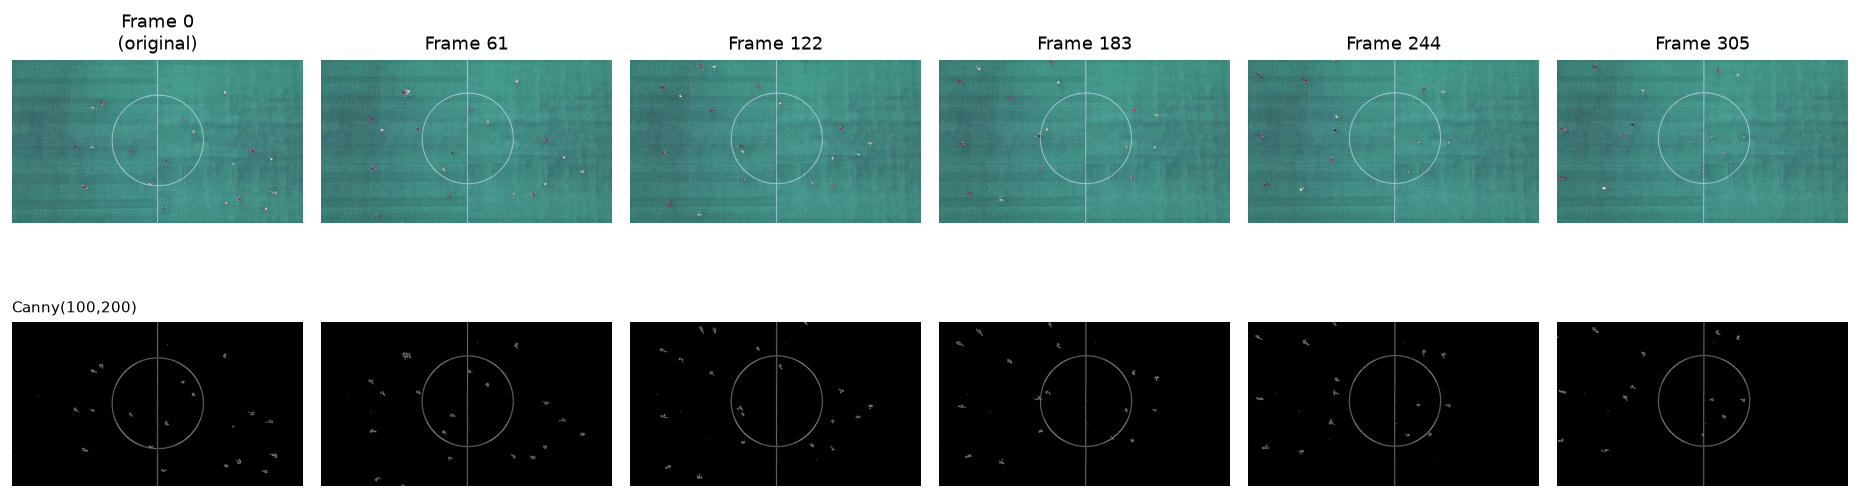

In [18]:
USE_WEBCAM = False  # True -> live cv2.VideoCapture(0); requires a display/camera on your machine
VIDEO_SOURCE = 0 if USE_WEBCAM else os.path.join(DATA_DIR, 'chp_01_images', 'football.mp4')


def run_live_canny(source=0, low=100, high=200):
    '''Interactive live Canny loop (blocking). Press "q" in the window to quit.'''
    cap = cv2.VideoCapture(source)
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, low, high)
        cv2.imshow('Canny Edges', edges)
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()


if USE_WEBCAM:
    run_live_canny(source=0)
else:
    cap = cv2.VideoCapture(VIDEO_SOURCE)
    assert cap.isOpened(), f'Could not open video source: {VIDEO_SOURCE}'
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    sample_idx = np.linspace(0, max(total_frames - 1, 0), 6).astype(int)

    frames, edges_list = [], []
    for idx in sample_idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue
        gray_f = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(frame)
        edges_list.append(cv2.Canny(gray_f, 100, 200))
    cap.release()

    fig, axes = plt.subplots(2, len(frames), figsize=(2.6 * len(frames), 5.2))
    for i in range(len(frames)):
        axes[0, i].imshow(bgr2rgb(frames[i])); axes[0, i].set_title(f'Frame {sample_idx[i]}'); axes[0, i].axis('off')
        axes[1, i].imshow(edges_list[i], cmap='gray'); axes[1, i].axis('off')
    axes[0, 0].set_title(f'Frame {sample_idx[0]}\n(original)')
    axes[1, 0].set_title('Canny(100,200)', loc='left', fontsize=9)
    plt.tight_layout()
    save_fig(fig, 'task6_video_canny_frames.png')
    plt.show()

**Observation.** Applying the identical `cv2.Canny(gray, 100, 200)` call frame-by-frame to a video is exactly how real-time edge detection is done -- the only difference from the single-image case is the acquisition loop. Across the sampled football-video frames, the players' silhouettes and the pitch markings are consistently detected, while motion blur on fast-moving limbs/ball noticeably thins or breaks up their edge contours frame to frame, illustrating why real-time edge-based tracking often needs temporal smoothing across frames in addition to per-frame Canny.

---
## Summary of Findings

| Task | Topic | Key Finding |
|---|---|---|
| 1 | Matplotlib + OpenCV | BGR->RGB conversion is mandatory before `imshow()`; the histogram's shape reveals overall image brightness/structure. |
| 2 | Morphology | Opening removes small bright specks while preserving object size; closing fills small dark holes the same way. |
| 3 | Smoothing | Bilateral filter best preserves edges while denoising; median filter is uniquely effective against salt-and-pepper noise; box and `filter2D`-mean are numerically equivalent. |
| 4 | Gradients | Sobel X/Y detect orthogonal edge orientations; magnitude combines both; direction feeds Canny's non-max-suppression. |
| 5 | Pyramids & Blending | Pyramid blending gives a seamless multi-scale result; additive blending saturates, weighted blending double-exposes. |
| 6 | Edge Detection | Canny gives the thinnest, most noise-robust edges via hysteresis; lower thresholds admit more (weaker) edges; the same per-frame call works unmodified on video. |

## Individual Contribution Summary

| Student | Contribution |
|---|---|
| Muhammad Umer (F2023266912) | Task 1 (Matplotlib + OpenCV), Task 2 (Morphology), Task 3 (Smoothing & Blurring) |
| Haseeb Ullah (F20232661009) | Task 4 (Gradients), Task 5 (Pyramids & Blending), Task 6 (Edge Detection) |

Both members reviewed and can independently explain every task in this notebook, as required for the in-class viva.